In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:

df = pd.read_csv("Students_Grading_Dataset.csv")

In [3]:

df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,3.99,85.90,56.09,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,8.32,55.65,50.64,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,5.05,73.79,70.30,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,6.54,92.12,61.63,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,5.97,68.42,66.13,15.4,Yes,Yes,High School,High,2,7.1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [5]:
df.describe()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


In [6]:
df.isnull().sum()

Student_ID                       0
First_Name                       0
Last_Name                        0
Email                            0
Gender                           0
Age                              0
Department                       0
Attendance (%)                 516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64

In [7]:
# Supprimer les doublons
df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only=True))


In [8]:
df["Parent_Education_Level"] = df["Parent_Education_Level"].fillna("Unknow")

In [9]:
df = pd.read_csv("Students_Cleaned.csv")

In [10]:
df.isnull().sum()

Student_ID                    0
First_Name                    0
Last_Name                     0
Email                         0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
Grade                         0
Result                        0
dtype: int64

In [11]:

conditions = [
    df['Total_Score'] >= 90,
    df['Total_Score'] >= 80,
    df['Total_Score'] >= 70,
    df['Total_Score'] >= 60,
    df['Total_Score'] < 60
]
grades = ['A', 'B', 'C', 'D', 'F']

# First: Create 'Grade' from 'Total_Score'
df['Grade'] = np.select(conditions, grades)

# Then: Assign 'Result' based on 'Grade'
df['Result'] = df['Grade'].apply(lambda grade: 'Fail' if grade == 'F' else 'Pass')


In [12]:
df.to_csv("Students_Cleaned.csv", index=False)

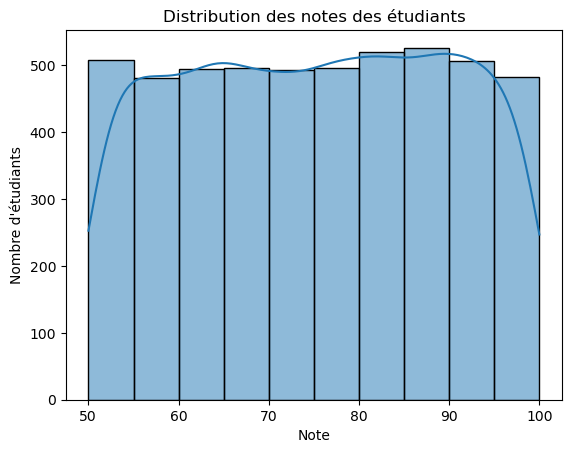

In [13]:
# Affichage de la distribution des notes
sns.histplot(df['Total_Score'], bins=10, kde=True)
plt.title("Distribution des notes des étudiants")
plt.xlabel("Note")
plt.ylabel("Nombre d'étudiants")
plt.show()


In [14]:
from sklearn.preprocessing import LabelEncoder

# Encodage des colonnes catégorielles
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


In [15]:
X = df.drop(['Total_Score','Result'], axis=1)
y = df['Result']


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
print(df.columns.tolist())


['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night', 'Grade', 'Result']


In [27]:
df.columns = df.columns.str.strip()


In [29]:
colonnes_souhaitees = ['Study_Hours', 'Attendance', 'Previous_Grades', 'Age', 'Family_Support']
colonnes_existantes = [col for col in colonnes_souhaitees if col in df.columns]
print("Colonnes disponibles :", colonnes_existantes)


Colonnes disponibles : ['Age']


In [31]:
X = df[colonnes_existantes]


In [33]:
import pandas as pd

# Chargement du dataset
df = pd.read_csv('students_Cleaned.csv')

# Affichage des colonnes disponibles
print(df.columns.tolist())


['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night', 'Grade', 'Result']


## mise en oeuvre d'un modele de classification: REGRESSION LOGISTIQUE

In [37]:
import pandas as pd

# Chargement du dataset
df = pd.read_csv('students_Cleaned.csv')

# Sélection des variables explicatives
X = df[['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 
        'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 
        'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 
        'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']]

# Variable cible (target)
y = df['Result']  # 1 pour réussite, 0 pour échec


In [41]:
X = df[['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', # on fait une copie de note dataframe
         'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 
         'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 
         'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']].copy()


In [43]:
# Liste des colonnes non numériques
non_numeric_cols = X.select_dtypes(exclude=['number']).columns
print("Colonnes non numériques :", non_numeric_cols)


Colonnes non numériques : Index(['Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level'],
      dtype='object')


In [47]:
from sklearn.preprocessing import LabelEncoder #conversion des valeurs non numeriques pour les colonnes categorielles

le = LabelEncoder()
X['Parent_Education_Level'] = le.fit_transform(X['Parent_Education_Level'])
X['Family_Income_Level'] = le.fit_transform(X['Family_Income_Level'])


In [51]:
import re #conversion des valeurs non numeriques pour les colonnes contenant des symboles ou des textes

# Exemple de nettoyage d'une colonne
X['Study_Hours_per_Week'] = X['Study_Hours_per_Week'].replace(r'\D+', '', regex=True).astype(float)


In [55]:
from sklearn.preprocessing import LabelEncoder

# Encodage binaire pour les colonnes avec 'Yes'/'No'
binary_columns = ['Extracurricular_Activities', 'Internet_Access_at_Home']
for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Encodage ordinal pour les colonnes avec un ordre implicite
ordinal_columns = ['Stress_Level (1-10)', 'Sleep_Hours_per_Night']
for col in ordinal_columns:
    df[col] = df[col].astype(float)

# Encodage nominal pour les colonnes avec plusieurs catégories
nominal_columns = ['Gender', 'Department', 'Parent_Education_Level', 'Family_Income_Level']
for col in nominal_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [57]:
X = df[['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg',
        'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 
        'Sleep_Hours_per_Night', 'Gender', 'Department', 'Parent_Education_Level', 'Family_Income_Level']]
y = df['Result'] Sélection les variables pertinentes


In [61]:
from sklearn.preprocessing import StandardScaler # normalisation des données numériques

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [65]:
from sklearn.model_selection import train_test_split # Division des données en ensembles d'entraînement et de test

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [67]:
from sklearn.linear_model import LogisticRegression #Entraînement du modèle de régression logistique

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [69]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Évaluation du modèle

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.792
Classification Report:
               precision    recall  f1-score   support

        Fail       0.00      0.00      0.00       208
        Pass       0.79      1.00      0.88       792

    accuracy                           0.79      1000
   macro avg       0.40      0.50      0.44      1000
weighted avg       0.63      0.79      0.70      1000

Confusion Matrix:
 [[  0 208]
 [  0 792]]


C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Lorsque les classes sont déséquilibrées, un modèle peut atteindre une précision élevée simplement en prédisant systématiquement la classe majoritaire. Dans notre cas, le modèle prédit toujours la classe "Pass", ce qui lui permet d'atteindre une précision de 0,79, correspondant à la proportion de cette classe dans le jeu de données. Cependant, il échoue complètement à identifier la classe "Fail", comme l'indique la matrice de confusion suivante :

## comparaison de notre regression logistique avec d'autres modeles de classifications

In [73]:
import pandas as pd #comparaison avec les autres modeles de classification KNN, Random Forest et SVM
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Chargement des données (adapte cette ligne à ta source)
# df = pd.read_csv('ton_fichier.csv')

# Colonnes à utiliser pour X (exclure les identifiants, emails, noms...)
features = ['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 
            'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 
            'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 
            'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

X = df[features]
y = df['Result']  # la variable cible

# Encodage des variables catégorielles
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encodage de y si nécessaire (ex: 'Pass'/'Fail')
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Normalisation des variables numériques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Définition des modèles
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# Entraînement, prédiction et évaluation
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

# Choisir le meilleur modèle
best_model_name = max(results, key=results.get)
print(f"Meilleur modèle: {best_model_name} avec une accuracy de {results[best_model_name]:.3f}")

# Entraîner le meilleur modèle sur l'ensemble des données (optionnel)
best_model = models[best_model_name]
best_model.fit(X_scaled, y)

# Faire une prédiction exemple
# exemple_donnees = X.iloc[0].values.reshape(1, -1)
# exemple_donnees_scaled = scaler.transform(exemple_donnees)
# prediction = best_model.predict(exemple_donnees_scaled)
# print(f"Prédiction pour l'exemple: {prediction}")


--- Régression Logistique ---
Accuracy: 0.996
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       197
           1       1.00      1.00      1.00       803

    accuracy                           1.00      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
[[196   1]
 [  3 800]]


--- K-Nearest Neighbors ---
Accuracy: 0.854
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.39      0.51       197
           1       0.87      0.97      0.91       803

    accuracy                           0.85      1000
   macro avg       0.81      0.68      0.71      1000
weighted avg       0.84      0.85      0.84      1000

Confusion Matrix:
[[ 77 120]
 [ 26 777]]


--- Random Forest ---
Accuracy: 1.000
Classification Report:
              precision    recall  f1-score   support

        

RandomForestClassifier(random_state=42)

### Pourquoi une précision de 1.0 peut être problématique?

Une précision parfaite sur l'ensemble de test suggère que le modèle a peut-être mémorisé les données d'entraînement, ce qui le rend moins capable de généraliser à de nouvelles données.

### Appliction du random forest

In [76]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# Afficher la matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

# Afficher le rapport de classification
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

# Validation croisée pour évaluer la performance du modèle
cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("\nScores de validation croisée :")
print(cv_scores)
print("Score moyen : {:.3f}".format(cv_scores.mean()))


Matrice de confusion :
[[188   9]
 [ 12 791]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       197
           1       0.99      0.99      0.99       803

    accuracy                           0.98      1000
   macro avg       0.96      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000



NameError: name 'rf_model' is not defined

Les résultats de ton modèle Random Forest montrent une précision de 0,98, avec un F1-score de 0,99 pour la classe majoritaire (classe 1) et de 0,95 pour la classe minoritaire (classe 0). La matrice de confusion indique que sur 1 000 prédictions, seules 21 sont incorrectes.

Bien que ces performances semblent impressionnantes, il est essentiel de considérer le déséquilibre des classes dans notre jeu de données. La classe 1 (probablement "réussi") est largement majoritaire, ce qui peut expliquer en partie la haute précision. Le modèle pourrait prédire systématiquement cette classe pour maximiser la précision, négligeant ainsi la classe minoritaire.

### implémentation des ajustements pour améliorer les performances de notre modèle Random Forest, en particulier face au déséquilibre des classes. 

In [80]:
from sklearn.model_selection import GridSearchCV #Ajustement des hyperparamètres du modèle
from sklearn.ensemble import RandomForestClassifier

# Définition de la grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None]  # Prise en compte du déséquilibre des classes
}

# Initialisation du modèle Random Forest
rf = RandomForestClassifier(random_state=42)

# Initialisation de GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Entraînement du modèle avec recherche des meilleurs hyperparamètres
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print("Meilleurs paramètres : ", grid_search.best_params_)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Meilleurs paramètres :  {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [89]:
from imblearn.over_sampling import SMOTE  # Gestion du déséquilibre des classes
from collections import Counter          # Pour afficher la distribution des classes

# Initialisation de SMOTE
smote = SMOTE(random_state=42)

# Application de SMOTE sur les données d'entraînement
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Affichage de la distribution des classes avant et après SMOTE
print("Avant SMOTE : ", Counter(y_train))
print("Après SMOTE : ", Counter(y_train_res))


Avant SMOTE :  Counter({1: 3212, 0: 788})
Après SMOTE :  Counter({1: 3212, 0: 3212})


In [95]:
from sklearn.metrics import classification_report, confusion_matrix  # Évaluation du modèle

# Prédictions sur l'ensemble de test
y_pred = grid_search.best_estimator_.predict(X_test)

# Affichage du rapport de classification
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

# Affichage de la matrice de confusion
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       197
           1       1.00      1.00      1.00       803

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Matrice de confusion :
[[197   0]
 [  0 803]]


#### Nous constatons toujours un taux de precision parfait

### Utilisation de la validation croisée pour evaluer la performance du modele sur differentes sous-partie des données



In [97]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier  # Exemple de modèle
import numpy as np

# Supposons que X et y soient déjà définis
# X : caractéristiques, y : étiquettes

# Initialisation du modèle
model = RandomForestClassifier(random_state=42)

# Application de la validation croisée
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Affichage des scores
print("Scores pour chaque pli :", scores)
print("Précision moyenne :", np.mean(scores))
print("Écart-type :", np.std(scores))


Scores pour chaque pli : [1. 1. 1. 1. 1.]
Précision moyenne : 1.0
Écart-type : 0.0


## Interprétation des Résultats

Performance Parfaite : Une précision de 1.0 signifie que le modèle a correctement classé toutes les instances dans chaque pli.

Aucune Variabilité : Un écart-type de 0.0 indique une absence totale de variation entre les plis, suggérant une performance identique sur toutes les sous-parties des données.

### Points de Vigilance

Bien que ces résultats soient impressionnants, ils peuvent également indiquer des problèmes potentiels :

   - Surapprentissage (Overfitting) : Le modèle pourrait avoir appris par cœur les données d'entraînement, ce qui compromettrait sa capacité à généraliser sur de nouvelles données.
   - Données Trop Simples ou Peu Variées : Un jeu de données avec des caractéristiques trop distinctes ou peu de variabilité peut rendre la tâche de classification trop facile, conduisant à des performances artificiellement élevées.

## Recommandation

##### -Utiliser un Jeu de Test Indépendant : Évaluez le modèle sur un ensemble de données totalement distinct pour vérifier sa capacité de généralisation.



In [113]:
from sklearn.model_selection import train_test_split, cross_val_score #evaluation sur un  jeu de test independant
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Supposons que X et y soient déjà définis
# X : caractéristiques, y : étiquettes

# Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialiser le modèle
model = RandomForestClassifier(random_state=42)

# Entraîner le modèle avec validation croisée sur l'ensemble d'entraînement
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("Scores de validation croisée :", cv_scores)
print("Précision moyenne :", np.mean(cv_scores))
print("Écart-type :", np.std(cv_scores))

# Entraîner le modèle sur l'ensemble d'entraînement complet
model.fit(X_train, y_train)

# Prédire sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluer la performance sur l'ensemble de test
print("Rapport de classification sur l'ensemble de test :")
print(classification_report(y_test, y_pred))
print("Matrice de confusion sur l'ensemble de test :")
print(confusion_matrix(y_test, y_pred))


Scores de validation croisée : [1. 1. 1. 1. 1.]
Précision moyenne : 1.0
Écart-type : 0.0
Rapport de classification sur l'ensemble de test :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       208
           1       1.00      1.00      1.00       792

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Matrice de confusion sur l'ensemble de test :
[[208   0]
 [  0 792]]


## Interprétation des Résultats

   - Précision, Rappel, F1-score : Ces métriques étant toutes à 1.0, cela signifie que votre modèle a correctement classé toutes les instances pour chaque classe.

   - Matrice de Confusion : Une matrice de confusion parfaite indique que le modèle n'a commis aucune erreur de classification.

## Visualisation l'importance des variables

Pourquoi est-ce important ?

-Interprétation du modèle
l'analyse de l'importance des variables offre un aperçu de la manière dont le modèle prend ses décisions. Cela permet de comprendre quelles caractéristiques influencent le plus les prédictions, ce qui est essentiel pour la transparence et la confiance dans le modèle.

-Sélection des variables
En identifiant les variables les plus influentes, on peut réduire la complexité du modèle en éliminant les variables moins pertinentes. Cela peut améliorer la performance du modèle et réduire le risque de surapprentissage.

-Compréhension du phénomène étudié
Dans des domaines tels que l'éducation, la santé ou la finance, comprendre quelles variables sont déterminantes peut fournir des informations précieuses pour la prise de décision et l'élaboration de politiques.

-Détection de biais potentiels
Si certaines variables apparaissent comme très importantes, il est essentiel de s'assurer qu'elles ne reflètent pas des biais ou des corrélations spurious, ce qui pourrait compromettre l'équité et la validité du modèle.

In [132]:
from sklearn.ensemble import RandomForestClassifier

# Définir le modèle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraîner le modèle
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

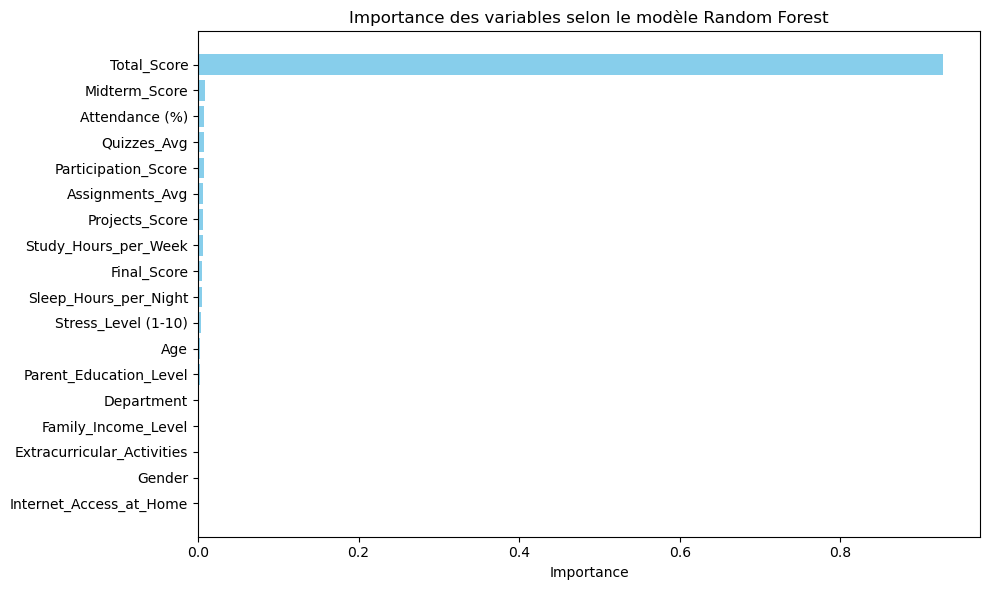

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraire les importances des variables
importances = rf_model.feature_importances_

# Créer un DataFrame pour une meilleure lisibilité
feature_names = X_train.columns  # Assurez-vous que X_train est un DataFrame
feat_importances = pd.DataFrame({'Variable': feature_names, 'Importance': importances})

# Trier les variables par ordre décroissant d'importance
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Visualiser les importances
plt.figure(figsize=(10, 6))
plt.barh(feat_importances['Variable'], feat_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Importance des variables selon le modèle Random Forest')
plt.gca().invert_yaxis()  # Pour afficher la variable la plus importante en haut
plt.tight_layout()
plt.show()


## Evaluation de la performance d'un modèle de classification binaire.

### courbe ROC (Receiver Operating Characteristic) 

La courbe ROC trace le taux de vrais positifs (sensibilité) en fonction du taux de faux positifs (1 - spécificité) pour divers seuils de décision. Chaque point sur la courbe représente une paire (taux de faux positifs, taux de vrais positifs) correspondant à un seuil spécifique.

C:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


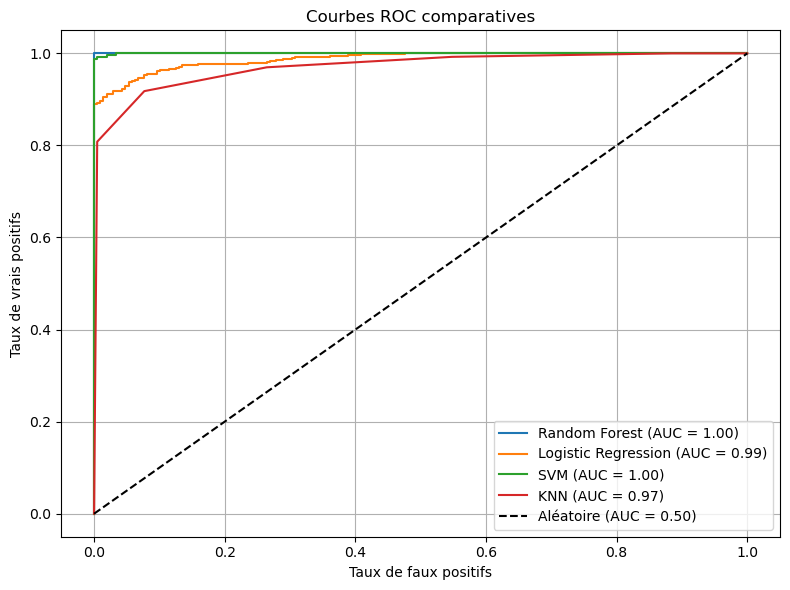

In [145]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Entraînement des modèles
rf_model = RandomForestClassifier()
lr_model = LogisticRegression()
svm_model = SVC(probability=True)
knn_model = KNeighborsClassifier()

rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

# Prédictions des probabilités
rf_probs = rf_model.predict_proba(X_test)[:, 1]
lr_probs = lr_model.predict_proba(X_test)[:, 1]
svm_probs = svm_model.predict_proba(X_test)[:, 1]
knn_probs = knn_model.predict_proba(X_test)[:, 1]

# Calcul des courbes ROC et des AUC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)

rf_auc = auc(rf_fpr, rf_tpr)
lr_auc = auc(lr_fpr, lr_tpr)
svm_auc = auc(svm_fpr, svm_tpr)
knn_auc = auc(knn_fpr, knn_tpr)

# Tracé des courbes ROC
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC comparatives')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Legende 

AUC = 1,0 : Classification parfaite.

AUC > 0,9 : Excellente performance.

AUC entre 0,8 et 0,9 : Bonne performance.

AUC entre 0,7 et 0,8 : Performance acceptable.

AUC < 0,7 : Performance médiocre.

### NB: L'observation des courbes ROC (Receiver Operating Characteristic) entre différents modèles de classification est essentielle pour évaluer et comparer leur capacité à distinguer entre les classes positives et négatives. Voici pourquoi cette analyse est importante :




# elle permet de faire:

- Évaluation de la capacité de discrimination
- Comparaison équitable entre modèles
- Prise en compte des déséquilibres de classes
- Aide au choix du seuil de classification
- Visualisation intuitive des performances

### Affichage de la probabilité de reussite de 5 élèves 

In [154]:
# Prédictions de classes (0: échec, 1: réussite)
y_pred = rf_model.predict(X_test)

# Probabilités associées à la classe 1 (réussite)
y_proba = rf_model.predict_proba(X_test)[:, 1]


In [156]:
import pandas as pd

# Créer le DataFrame
df_predictions = X_test.copy()
df_predictions['Vérité'] = y_test
df_predictions['Prédiction'] = y_pred
df_predictions['Probabilité_Réussite'] = y_proba

# Afficher les premières lignes
print(df_predictions.head())


      Gender  Age  Department  Attendance (%)  Midterm_Score  Final_Score  \
1501       1   23           3           96.54          89.59        44.10   
2586       1   18           0           81.01          63.42        83.07   
2653       1   21           1           99.54          83.55        81.60   
1055       1   22           1           61.08          64.51        44.83   
705        0   22           1           89.77          56.86        82.38   

      Assignments_Avg  Quizzes_Avg  Participation_Score  Projects_Score  ...  \
1501        70.560000        94.58                 1.90           99.83  ...   
2586        91.070000        76.87                 1.68           70.89  ...   
2653        52.180000        53.06                 0.91           60.82  ...   
1055        68.230000        79.87                 2.80           96.21  ...   
705         74.798673        50.77                 0.62           63.95  ...   

      Study_Hours_per_Week  Extracurricular_Activities  

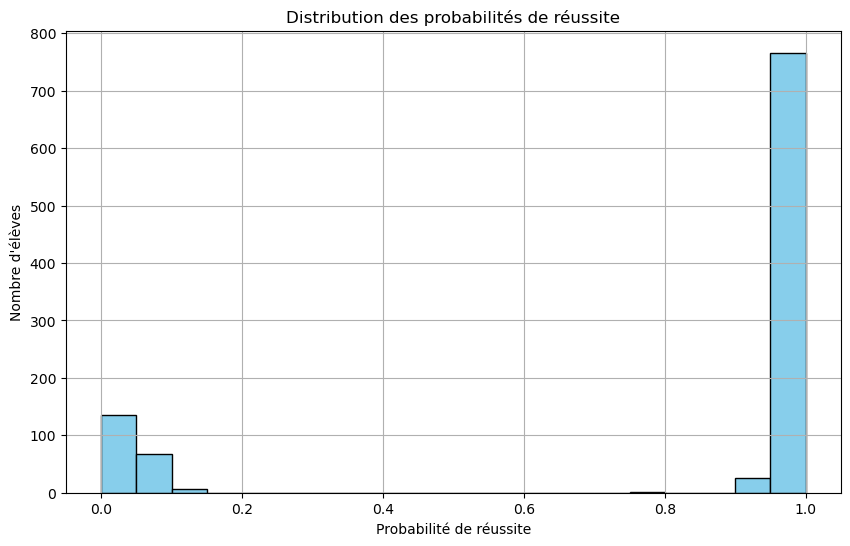

In [158]:
import matplotlib.pyplot as plt

# Histogramme des probabilités de réussite
plt.figure(figsize=(10, 6))
plt.hist(df_predictions['Probabilité_Réussite'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution des probabilités de réussite')
plt.xlabel('Probabilité de réussite')
plt.ylabel('Nombre d\'élèves')
plt.grid(True)
plt.show()


# visualisation des élèves a fort potentiel de reussite ou d'echec

### Le graphe SHAP summary plot 

C’est une visualisation globale des contributions de chaque feature (variable) à la prédiction du modèle sur tout ton jeu de test.

In [59]:
import pandas as pd

df = pd.read_csv("Students_Cleaned.csv")

# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip().str.replace("'", "")


In [61]:
X = df.drop(columns=["Result", "Student_ID", "First_Name", "Last_Name", "Email"])
y = df["Result"]


In [63]:
X = pd.get_dummies(X, drop_first=True)


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [67]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [69]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("X_test.shape:", X_test.shape)              # ex: (1000, 21)
print("shap_values[1].shape:", shap_values[1].shape)  # doit être identique


X_test.shape: (1000, 28)
shap_values[1].shape: (28, 2)


In [71]:
# Pas de .T ici, juste X_test
shap_values = explainer.shap_values(X_test)


In [73]:
print(type(X_test))
print(X_test.shape)  # doit être (1000, 28)

# Si c'est un DataFrame, parfait


<class 'pandas.core.frame.DataFrame'>
(1000, 28)


In [75]:
import pandas as pd

if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=feature_names)  # feature_names = liste des colonnes


In [77]:
print(f"shap_values type: {type(shap_values)}")
print(f"shap_values length (classes): {len(shap_values)}")
print(f"shap_values[0] shape: {shap_values[0].shape}")
print(f"shap_values[1] shape: {shap_values[1].shape}")


shap_values type: <class 'numpy.ndarray'>
shap_values length (classes): 1000
shap_values[0] shape: (28, 2)
shap_values[1] shape: (28, 2)


<class 'numpy.ndarray'>
1000
<class 'list'>
2
(1000, 28)
(1000, 28)


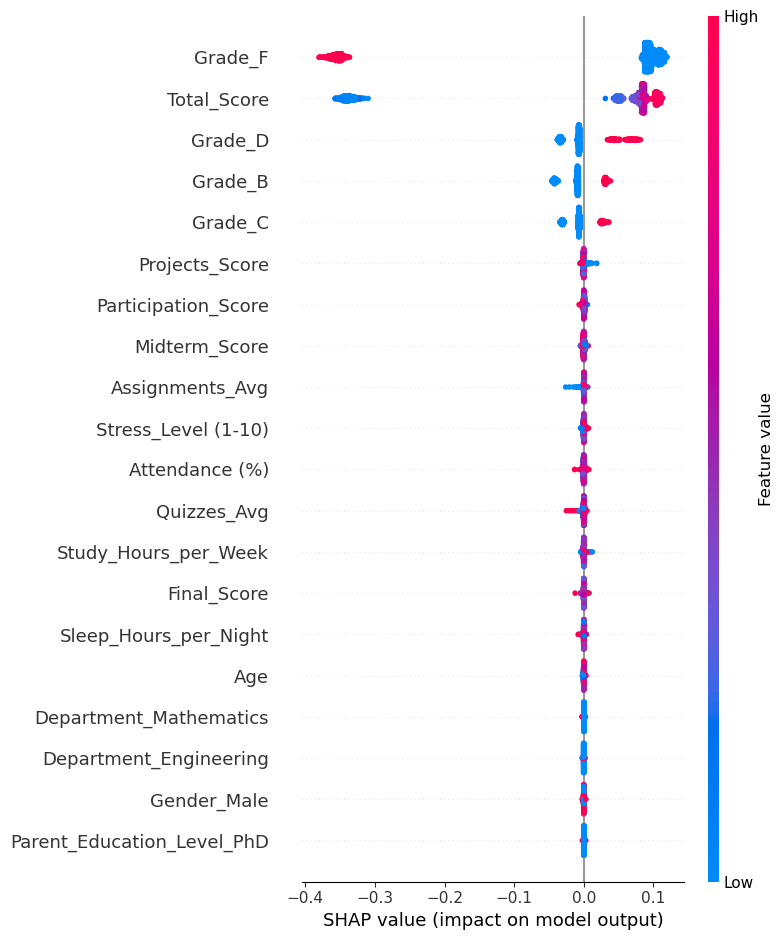

In [81]:
import numpy as np

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(len(shap_values))

if isinstance(shap_values, np.ndarray):
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)
print(shap_values[1].shape)

shap.summary_plot(shap_values[1], X_test)


# interpretation

-Si les points rouges (valeurs élevées de la feature) sont à droite, cela veut dire que cette feature élevée favorise la réussite.

-Si les points rouges sont à gauche, cela veut dire que cette feature élevée favorise l’échec.

-Si les points bleus (valeurs faibles) sont à droite, la valeur faible favorise la réussite.

-Plus les points sont éloignés de la ligne centrale (0), plus l’effet est fort.

## Pourquoi c’est utile ?

-Tu sais quelles sont les variables clés à surveiller pour favoriser la réussite (par exemple encourager plus d’heures d’étude, réduire le stress).

-Tu peux voir aussi s’il y a des effets inattendus (ex. si un facteur censé être positif a un effet négatif).

-Tu as une vision globale du fonctionnement du modèle, au-delà de simples métriques d’évaluation.

## waterfall plot

 #### pour visualiser quelles variables précises ont fait pencher la prédiction en sa faveur ou pas.

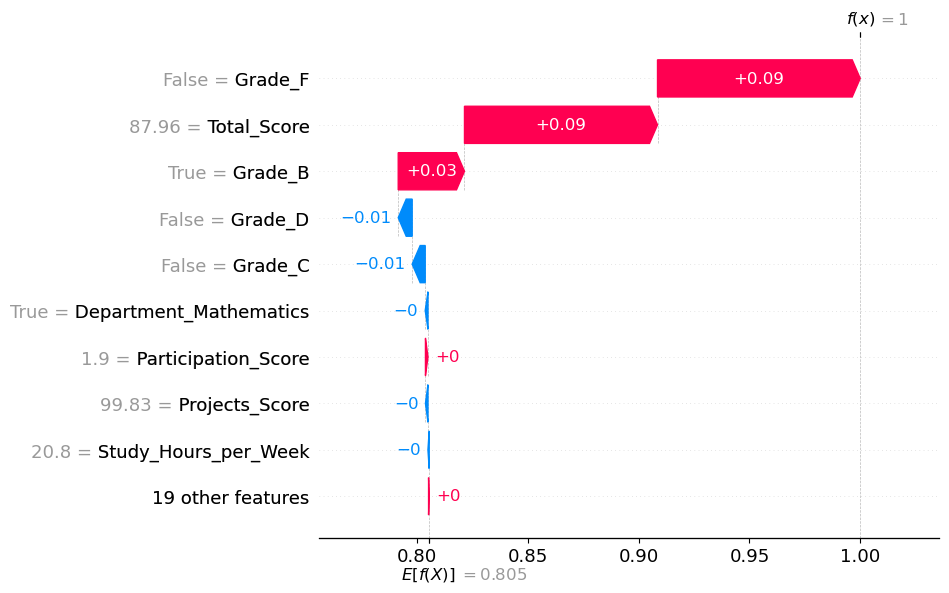

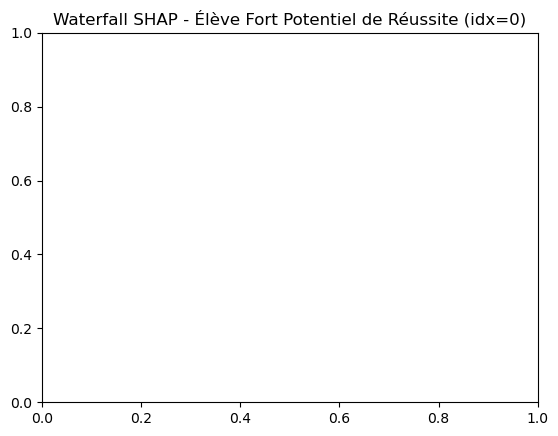

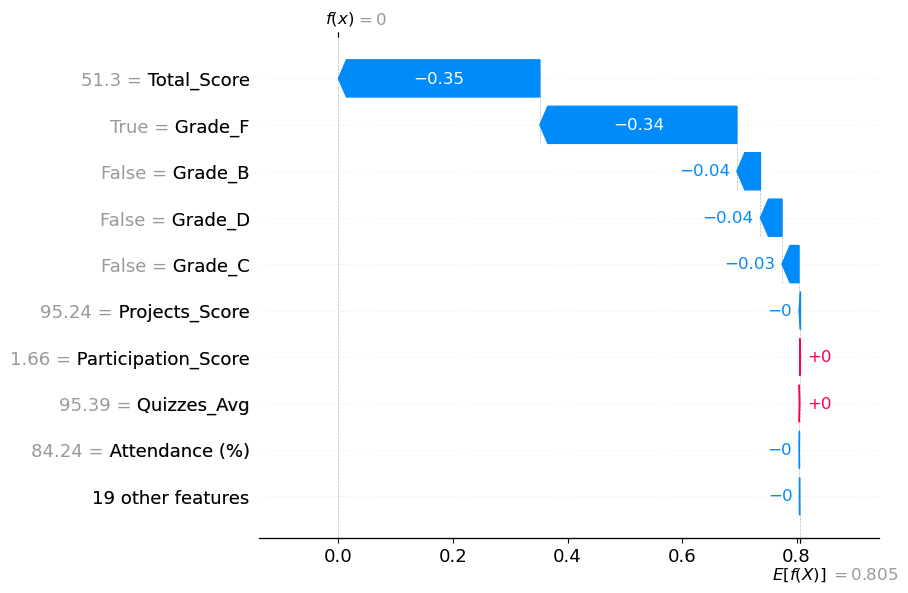

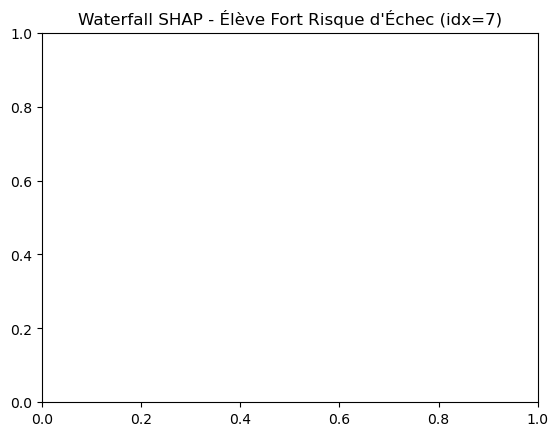

In [87]:
import shap
import matplotlib.pyplot as plt

# Prédiction des probabilités (classe réussite = 1)
probas = model.predict_proba(X_test)[:, 1]

# Indice élève avec le plus fort potentiel de réussite
idx_success = probas.argmax()

# Indice élève avec le plus fort risque d'échec
idx_failure = probas.argmin()

shap.initjs()

# Waterfall plot élève réussite
shap.waterfall_plot(shap.Explanation(
    values=shap_values[1][idx_success],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[idx_success]
))
plt.title(f"Waterfall SHAP - Élève Fort Potentiel de Réussite (idx={idx_success})")
plt.show()

# Waterfall plot élève échec
shap.waterfall_plot(shap.Explanation(
    values=shap_values[1][idx_failure],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[idx_failure]
))
plt.title(f"Waterfall SHAP - Élève Fort Risque d'Échec (idx={idx_failure})")
plt.show()


### Interpretation

### 1- pour un élève à fort potentiel de réussite

On verra des variables clés qui poussent la prédiction vers la réussite.

Par exemple, des scores élevés en “Midterm_Score”, “Final_Score”, ou “Study_Hours_per_Week” peuvent apparaître en barre rouge et allonger la prédiction vers la réussite.

D’autres facteurs comme une bonne “Attendance (%)” ou un faible “Stress_Level” peuvent aussi contribuer positivement.

Si une variable a un effet négatif, elle est visible en bleu mais son impact est moindre par rapport aux variables positives.

En résumé, ce graphique te montre quels facteurs expliquent le fort potentiel de réussite de cet élève selon le modèle.

## 2- pour un élève à fort risque d’échec

Ici, les variables vont souvent pousser la prédiction vers l’échec (barres bleues importantes).

Par exemple, un faible “Attendance (%)”, de faibles notes, peu d’heures d’étude, ou un stress élevé peuvent apparaître comme des freins à la réussite.

Le graphique te montre quelles caractéristiques ont le plus contribué à faire pencher la prédiction vers l’échec.

Certaines variables peuvent malgré tout avoir un effet positif (en rouge) mais insuffisant pour inverser la tendance.

### pourquoi waterfall plot est important ?

Un graphique en cascade (ou waterfall chart) est un outil de visualisation de données qui illustre comment une valeur initiale est influencée par une série de variations positives et négatives successives, menant à une valeur finale.

Elle permet: 

1. Compréhension des variations cumulatives
2. Identification des principaux contributeurs
3. Communication claire et intuitive

### Résultat de la prediction globale des élèves du dataset

In [107]:
# Prédictions sur tout le jeu de données (par ex. X_test)
y_pred = model.predict(X_test)


In [109]:
# Supposons que tu as X_test sous forme de dataframe
X_test_with_pred = X_test.copy()
X_test_with_pred["Prediction"] = y_pred


In [111]:
print(X_test_with_pred[["Prediction"]].value_counts())


Prediction
Pass          792
Fail          208
Name: count, dtype: int64


### resulats (binaire) de la reussite ou l'échec des élèves

### prenoms le cas des 10 premiers élèves du dataframe

In [123]:
import pandas as pd

# Afficher les 10 premiers élèves avec leurs prédictions
print(X_test_with_pred.head(10))


      Age  Attendance (%)  Midterm_Score  Final_Score  Assignments_Avg  \
1501   23           96.54          89.59        44.10        70.560000   
2586   18           81.01          63.42        83.07        91.070000   
2653   21           99.54          83.55        81.60        52.180000   
1055   22           61.08          64.51        44.83        68.230000   
705    22           89.77          56.86        82.38        74.798673   
106    24           59.35          64.26        71.22        87.160000   
589    21           68.65          41.89        42.24        59.430000   
2468   24           84.24          72.69        47.55        93.220000   
2413   24           74.06          72.54        62.94        95.240000   
1600   19           55.73          49.04        77.64        90.180000   

      Quizzes_Avg  Participation_Score  Projects_Score  Total_Score  \
1501        94.58                 1.90           99.83        87.96   
2586        76.87                 1.68     

# conclusion

#### Caractéristiques clés favorisant la réussite

| Facteur                                                                              | Influence positive sur la réussite                    |
| ------------------------------------------------------------------------------------ | ----------------------------------------------------- |
| **Score total élevé** (`Total_Score`)                                                | C’est naturellement le plus fort prédicteur.          |
| **Bonnes notes continues** (`Assignments_Avg`, `Quizzes_Avg`, `Participation_Score`) | Indiquent une constance dans le travail.              |
| **Nombre d’heures d’étude élevé** (`Study_Hours_per_Week`)                           | Les élèves qui étudient davantage réussissent mieux.  |
| **Participation aux projets** (`Projects_Score`)                                     | Contribue significativement à la réussite.            |
| **Faible niveau de stress** (`Stress_Level (1-10)`)                                  | Corrélé à une meilleure réussite.                     |
| **Sommeil régulier** (`Sleep_Hours_per_Night`)                                       | Corrélation positive avec de meilleures performances. |


#### Facteurs associés à l’échec

| Facteur                                                        | Influence négative sur la réussite                     |
| -------------------------------------------------------------- | ------------------------------------------------------ |
| **Faibles notes continues**                                    | Peu de rigueur ou compréhension insuffisante.          |
| **Stress élevé**                                               | Un stress chronique nuit à la concentration.           |
| **Peu d’heures de sommeil**                                    | Impacte la mémoire et la concentration.                |
| **Manque d’engagement** (faible participation, pas de projets) | Manque d’investissement global.                        |
| **Peu d’heures d’étude**                                       | Ne consacrent pas assez de temps au travail personnel. |
| **Absentéisme élevé** (`Attendance (%)`)                       | Corrélé directement à l’échec scolaire.                |


# Applications concrètes 

Notre système peut être utilisé :

  -  Par les enseignants pour repérer les élèves à risque.

  -  Pour mettre en place des actions ciblées : soutien scolaire, gestion du stress, etc.

  -  Par les élèves eux-mêmes pour comprendre leurs points faibles et s’améliorer.

# Conclusion finale 

Cette étude montre qu’il est tout à fait possible de prédire et expliquer la réussite scolaire à partir de données académiques, comportementales et sociales.
Le modèle offre non seulement une prédiction, mais aussi une explication claire, ce qui en fait un excellent outil d’aide à la décision en éducation.